In [1]:
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(2003)
np.random.seed(2003)

In [2]:
class Saw(nn.Module):
    def forward(self, x):
        return torch.abs(torch.remainder(x, 1.0) - 0.5) - 0.25


class MountainGen(nn.Module):
    def __init__(self, octaves=4, hidden=32, latent=4):
        super().__init__()
        self.encoders = nn.ModuleList(
            [nn.Linear(2, latent) for _ in range(octaves)],
        )
        self.noise = nn.Sequential(
            nn.Linear(latent, hidden),
            Saw(),
            nn.Linear(hidden, 1),
        )
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.5)
            nn.init.normal_(m.bias, 0.0, 0.5)

    def forward(self, coords):
        zs = [self.noise(enc(coords)) for enc in self.encoders]
        z = torch.stack(zs, dim=0).mean(dim=0)
        return (1 - torch.abs(z)) / (1 + torch.norm(coords, dim=-1, keepdim=True) ** 2)


base_model = MountainGen()  # f(x, y) = z
print(sum(p.numel() for p in base_model.parameters()), "parameters")
base_model.eval()

241 parameters


MountainGen(
  (encoders): ModuleList(
    (0-3): 4 x Linear(in_features=2, out_features=4, bias=True)
  )
  (noise): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Saw()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [3]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def evaluate_on_grid(
    model, offset=(0, 0), x_range=(-1, 1), y_range=(-1, 1), resolution=128
):
    x = offset[0] + np.linspace(x_range[0], x_range[1], resolution)
    y = offset[1] + np.linspace(y_range[0], y_range[1], resolution)
    xx, yy = np.meshgrid(x, y)
    grid = np.stack([xx.flatten(), yy.flatten()], axis=-1)

    with torch.no_grad():
        inputs = torch.from_numpy(grid).float()
        raw = model(inputs).detach().cpu().numpy()
        if raw.ndim == 2 and raw.shape[1] == 1:
            raw = raw[:, 0]
        elif raw.ndim != 1:
            raise ValueError(
                f"Model must return one value per grid point, got shape {raw.shape}"
            )
        outputs = raw.reshape(resolution, resolution)

    return x, y, xx, yy, outputs


def plot_landscape(x, y, xx, yy, outputs):
    fig = make_subplots(
        rows=2,
        cols=1,
        specs=[[{"type": "surface"}], [{"type": "heatmap"}]],
        subplot_titles=("Surface", "Heightmap"),
        vertical_spacing=0.08,
    )

    fig.add_trace(
        go.Surface(z=outputs, x=xx, y=yy, colorscale="Earth", showscale=False),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Heatmap(
            z=outputs, x=x, y=y, colorscale="Earth", colorbar=dict(title="height")
        ),
        row=2,
        col=1,
    )

    fig.update_xaxes(title_text="x", row=1, col=1)
    fig.update_yaxes(title_text="y", row=1, col=1)
    fig.update_scenes(xaxis_title="x", yaxis_title="y", zaxis_title="height")
    fig.update_layout(height=1200, width=680, title="Landscape")
    fig.show()


offset = (0, 0)
r = 1
x, y, xx, yy, height = evaluate_on_grid(
    base_model, offset, x_range=(-r, r), y_range=(-r, r)
)
plot_landscape(x, y, xx, yy, height)

In [4]:
import numba as nb


@nb.njit
def sample_height_and_gradient(heightmap, x_pos, y_pos):
    x0 = int(x_pos)
    y0 = int(y_pos)
    x1 = x0 + 1
    y1 = y0 + 1

    sx = x_pos - x0
    sy = y_pos - y0

    h00 = heightmap[y0, x0]
    h10 = heightmap[y0, x1]
    h01 = heightmap[y1, x0]
    h11 = heightmap[y1, x1]

    h0 = h00 * (1.0 - sx) + h10 * sx
    h1 = h01 * (1.0 - sx) + h11 * sx
    h = h0 * (1.0 - sy) + h1 * sy

    grad_x = (h10 - h00) * (1.0 - sy) + (h11 - h01) * sy
    grad_y = (h01 - h00) * (1.0 - sx) + (h11 - h10) * sx
    return h, grad_x, grad_y


@nb.njit
def deposit_bilinear(heightmap, x_pos, y_pos, amount):
    x0 = int(x_pos)
    y0 = int(y_pos)
    x1 = x0 + 1
    y1 = y0 + 1

    sx = x_pos - x0
    sy = y_pos - y0

    w00 = (1.0 - sx) * (1.0 - sy)
    w10 = sx * (1.0 - sy)
    w01 = (1.0 - sx) * sy
    w11 = sx * sy

    heightmap[y0, x0] += amount * w00
    heightmap[y0, x1] += amount * w10
    heightmap[y1, x0] += amount * w01
    heightmap[y1, x1] += amount * w11


@nb.njit
def erode_with_brush(heightmap, x_pos, y_pos, amount, radius):
    center_x = int(x_pos)
    center_y = int(y_pos)
    h = heightmap.shape[0]
    w = heightmap.shape[1]

    total_weight = 0.0
    for oy in range(-radius, radius + 1):
        for ox in range(-radius, radius + 1):
            xi = center_x + ox
            yi = center_y + oy
            if xi <= 0 or xi >= w - 1 or yi <= 0 or yi >= h - 1:
                continue
            dist = (ox * ox + oy * oy) ** 0.5
            if dist > radius:
                continue
            total_weight += radius + 1.0 - dist

    if total_weight <= 0.0:
        return 0.0

    removed = 0.0
    for oy in range(-radius, radius + 1):
        for ox in range(-radius, radius + 1):
            xi = center_x + ox
            yi = center_y + oy
            if xi <= 0 or xi >= w - 1 or yi <= 0 or yi >= h - 1:
                continue
            dist = (ox * ox + oy * oy) ** 0.5
            if dist > radius:
                continue

            weight = radius + 1.0 - dist
            share = amount * (weight / total_weight)

            local_floor = 1e18
            for ny in range(yi - 1, yi + 2):
                for nx in range(xi - 1, xi + 2):
                    if ny == yi and nx == xi:
                        continue
                    v = heightmap[ny, nx]
                    if v < local_floor:
                        local_floor = v

            max_remove = heightmap[yi, xi] - local_floor
            if max_remove < 0.0:
                max_remove = 0.0

            delta = share
            if delta > max_remove:
                delta = max_remove

            heightmap[yi, xi] -= delta
            removed += delta

    return removed


@nb.njit
def diffuse_step(heightmap, alpha):
    src = heightmap.copy()
    h = heightmap.shape[0]
    w = heightmap.shape[1]

    for yi in range(1, h - 1):
        for xi in range(1, w - 1):
            lap = (
                src[yi - 1, xi]
                + src[yi + 1, xi]
                + src[yi, xi - 1]
                + src[yi, xi + 1]
                - 4.0 * src[yi, xi]
            )
            heightmap[yi, xi] = src[yi, xi] + alpha * lap


@nb.njit
def hydraulic_erosion_numba(
    orig_heightmap,
    start_x,
    start_y,
    max_steps,
    inertia,
    capacity,
    min_slope,
    deposition,
    erosion,
    evaporation,
    gravity,
    max_deposit_step,
    max_erode_step,
    brush_radius,
    diffuse_every,
    diffuse_alpha,
):
    hm = orig_heightmap.copy()
    h = hm.shape[0]
    w = hm.shape[1]
    iterations = start_x.shape[0]

    for drop_idx in range(iterations):
        x_pos = start_x[drop_idx]
        y_pos = start_y[drop_idx]

        dir_x = 0.0
        dir_y = 0.0
        # speed = 1.0
        water = capacity
        sediment = 0.0

        for _ in range(max_steps):
            if x_pos < 1.0 or x_pos >= w - 2.0 or y_pos < 1.0 or y_pos >= h - 2.0:
                break

            h_now, grad_x, grad_y = sample_height_and_gradient(
                orig_heightmap, x_pos, y_pos
            )

            dir_x = dir_x * inertia - grad_x * (1.0 - inertia)
            dir_y = dir_y * inertia - grad_y * (1.0 - inertia)

            norm = (dir_x * dir_x + dir_y * dir_y) ** 0.5
            if norm < 1e-12:
                break

            dir_x /= norm
            dir_y /= norm

            new_x = x_pos + dir_x
            new_y = y_pos + dir_y
            if new_x < 1.0 or new_x >= w - 2.0 or new_y < 1.0 or new_y >= h - 2.0:
                break

            h_new, _, _ = sample_height_and_gradient(orig_heightmap, new_x, new_y)
            delta_h = h_new - h_now

            # seems like slope does not do much
            slope = -delta_h
            if slope < min_slope:
                slope = min_slope
            sediment_capacity = water * slope  # slope * speed * water

            if delta_h > 0.0 or sediment > sediment_capacity:
                # target = (
                #     delta_h
                #     if delta_h > 0.0
                #     else (sediment - sediment_capacity) * deposition
                # )
                # deposit_amount = sediment
                # if target < deposit_amount:
                #     deposit_amount = target
                # if max_deposit_step < deposit_amount:
                #     deposit_amount = max_deposit_step

                # if deposit_amount > 0.0:
                #     deposit_bilinear(hm, x_pos, y_pos, deposit_amount)
                #     sediment -= deposit_amount
                pass
            else:
                # erode_amount = (sediment_capacity - sediment) * erosion
                erode_amount = sediment_capacity * erosion
                # downhill_limit = -delta_h
                # if downhill_limit < erode_amount:
                #     erode_amount = downhill_limit
                if max_erode_step < erode_amount:
                    erode_amount = max_erode_step

                if erode_amount > 0.0:
                    lifted = erode_with_brush(
                        hm, x_pos, y_pos, erode_amount, brush_radius
                    )
                    # sediment += lifted

            # speed_sq = speed * speed + (-delta_h) * gravity
            # if speed_sq < 0.05:
            #     speed_sq = 0.05
            # speed = speed_sq**0.5
            # if speed > 3.0:
            #     speed = 3.0

            water *= 1.0 - evaporation
            x_pos = new_x
            y_pos = new_y

            if water < 0.02:
                break

        # if diffuse_every > 0 and ((drop_idx + 1) % diffuse_every == 0):
        #     diffuse_step(hm, diffuse_alpha)

    return hm


def hydraulic_erosion(
    heightmap,
    iterations=128 * 128,
    max_steps=8,
    erosion=0.2,
    max_erode_step=0.02,
    capacity=1.6,
    evaporation=0.01,
    brush_radius=1,
    min_slope=0.01,
    inertia=0.0,  # removed
    gravity=4.0,  # removed
    deposition=0.0,  # removed
    max_deposit_step=0.0,  # removed
    diffuse_every=6000,  # removed
    diffuse_alpha=0.01,  # removed
    seed=None,
):
    rng = np.random.default_rng(seed)
    h, w = heightmap.shape
    start_x = rng.uniform(1.0, w - 2.0, size=iterations).astype(np.float64)
    start_y = rng.uniform(1.0, h - 2.0, size=iterations).astype(np.float64)

    hm64 = np.asarray(heightmap, dtype=np.float64)
    eroded = hydraulic_erosion_numba(
        hm64,
        start_x,
        start_y,
        max_steps,
        inertia,
        capacity,
        min_slope,
        deposition,
        erosion,
        evaporation,
        gravity,
        max_deposit_step,
        max_erode_step,
        int(brush_radius),
        int(diffuse_every),
        diffuse_alpha,
    )
    return eroded.astype(heightmap.dtype, copy=False)


eroded_height = hydraulic_erosion(height)
plot_landscape(x, y, xx, yy, eroded_height)


def plot_heatmap(diff, name):
    fig = go.Figure(data=go.Heatmap(z=diff, colorscale="RdBu"))
    fig.update_layout(height=680, width=680, title=name)
    fig.show()


def plot_diff_heatmap(diff):
    plot_heatmap(diff, "Height Difference")


height_diff = eroded_height - height
plot_diff_heatmap(height_diff)

In [ ]:
# accumulated path integral idea:

# def step_evolve(prev: [W, H], gradient_field: [W, H, 2], act=sigmoid/softmax, temperature=0.1, evaporate=0.01, min_slope):
#   directions = [[1, 0], [0, 1], [-1, 0], [0, -1]] / temperature
#   returns next [W, H], where
#   distributions: [W, H, 4]
#   for each cell in prev:
#      slope = norm of gradient_field[i, j]
#      distributions[i, j, 0-4] = slope.clamp(min_slope) * (1 - evaporate) * prev[i, j] * (softmax(gradient_field[i+1, j] dot directions[0], ...) or sigmoid(gradient_field[i+1, j] dot directions[0], ...)/2.0)
#   next = 0
#   for each cell in next:
#     next[i, j] = sum(distributions[a, b, k] for a, b, k in [[i+1, j, 2], [i, j+1, 3], [i-1, j, 0], [i, j-1, 1]])
#   return next

# def accumulated_path_integrals(gradient_field: [W, H, 2], act=sigmoid/softmax, temperature=0.1, evaporate=0.01, steps=8, normalize=True, min_slope):
#   acc: [W,H] = 0
#   state: [W, H] = 1
#   for i in range(steps):
#     acc += state
#     state = step_evolve(state, gradient_field, act, temperature, evaporate, min_slope)
#   return acc / sum(acc) if normalize else acc

# a optimized version of the above in torch:

import torch
import torch.nn.functional as F


def precompute_distributions(
    gradient_field: torch.Tensor, act="softmax", temperature=0.1
):
    """
    Precompute per-cell normalized distributions from a static gradient field.
    distrib[i,j,:] >= 0 and sum=1 per cell
    """
    device = gradient_field.device
    dtype = gradient_field.dtype

    directions = (
        torch.tensor([[1, 0], [0, 1], [-1, 0], [0, -1]], dtype=dtype, device=device)
        / temperature
    )
    dots = torch.einsum("whd,nd->whn", gradient_field, directions)

    if act == "softmax":
        distrib = F.softmax(dots, dim=-1)
    elif act == "sigmoid":
        s = torch.sigmoid(dots)
        distrib = s / s.sum(dim=-1, keepdim=True)
    else:
        raise ValueError("act must be 'softmax' or 'sigmoid'")

    return distrib


def transport_once(x: torch.Tensor, distrib: torch.Tensor):
    out = distrib * x.unsqueeze(-1)

    y = torch.zeros_like(x)

    y[1:, :] += out[:-1, :, 0]
    y[:, 1:] += out[:, :-1, 1]
    y[:-1, :] += out[1:, :, 2]
    y[:, :-1] += out[:, 1:, 3]

    return y


def accumulated_path_integrals(
    grad_magnitudes: torch.Tensor,
    distrib: torch.Tensor,
    evaporate=0.01,
    steps=8,
    max_erode_step=0.012,
    source_scale=0.01,
    min_slope=0.01,
):
    persist = 1 - evaporate
    W, H, _ = distrib.shape
    device = distrib.device
    dtype = distrib.dtype

    source = torch.ones(W, H, dtype=dtype, device=device) * source_scale
    Q = source.clone()

    grad_magnitudes = grad_magnitudes.clamp(min=min_slope)

    for _ in range(steps):
        erode_step = grad_magnitudes * persist * transport_once(Q, distrib)
        Q = source + torch.clamp(erode_step, max=max_erode_step)

    return Q

In [ ]:
import torch


# def calculate_ITV(acc_integral: torch.Tensor, d=1.0):
#     right_diff = torch.abs(acc_integral[1:, :] - acc_integral[:-1, :])
#     down_diff = torch.abs(acc_integral[:, 1:] - acc_integral[:, :-1])
#     tv = (right_diff.sum() + down_diff.sum()) * (d**2)
#     return 1 / tv


def calculate_PR(
    acc_integral: torch.Tensor,
    power=0.7,
    d=1.0,
    normalize=False,
    inverse=False,
):
    if normalize:
        numerator = (acc_integral * (d**2)).sum() ** power
    else:
        numerator = 1.0
    denominator = ((acc_integral**power) * (d**2)).sum()
    if denominator == 0:
        return float("inf")
    return numerator / denominator if not inverse else denominator / numerator


def calculate_Ediss(acc_integral: torch.Tensor, power=0.7, d=1.0):
    """
    Compute energy dissipation from accumulated path integrals.

    acc_integral: [W,H] accumulated path integral
    power: exponent for dissipation (default 2 corresponds to squared gradient)
    d: grid spacing (for normalization)

    Returns: Ediss [W,H]
    """
    # Compute finite differences (forward/backward) to approximate gradient
    # Gradient in x
    grad_x = torch.zeros_like(acc_integral)
    grad_x[1:, :] = acc_integral[1:, :] - acc_integral[:-1, :]
    grad_x[0, :] = grad_x[1, :]  # replicate first row

    # Gradient in y
    grad_y = torch.zeros_like(acc_integral)
    grad_y[:, 1:] = acc_integral[:, 1:] - acc_integral[:, :-1]
    grad_y[:, 0] = grad_y[:, 1]  # replicate first column

    # Energy dissipation: norm of gradient to the given power
    Ediss = (grad_x**2 + grad_y**2) ** (power) / (d**power)
    return Ediss

In [ ]:
def plot_acc_heatmap(diff):
    plot_heatmap(diff, "Accumulated Path Integral")


# plot accumulated path integral as heatmap for the example heightmap:
gradient_field = torch.from_numpy(np.stack(np.gradient(height), axis=-1)).float()
distrib = precompute_distributions(-gradient_field, act="softmax", temperature=0.01)
grad_magnitudes = torch.norm(gradient_field, dim=-1)
plot_acc_heatmap(
    accumulated_path_integrals(
        grad_magnitudes, distrib, steps=128, evaporate=0.01, max_erode_step=0.02
    )
)
# print(calculate_PR(acc_integral, d=2.0 / height.shape[0], inverse=True, normalize=True))


# problems:
# 1. a cell must have max capacity and redistribute when overflowed
# 2. better to have not water amount per cell, but the amount of flow passing through the cell

In [ ]:
eheight = height.copy()

strength = 0.005

gradient_field = torch.from_numpy(np.stack(np.gradient(eheight), axis=-1)).float()
distrib = precompute_distributions(-gradient_field, act="softmax", temperature=0.01)
grad_magnitudes = torch.norm(gradient_field, dim=-1)
acc_integral = (
    accumulated_path_integrals(
        grad_magnitudes, distrib, steps=128, evaporate=0.01, max_erode_step=0.02
    )
    * strength
)
eheight -= acc_integral.cpu().numpy()

plot_landscape(x, y, xx, yy, eheight)

In [ ]:
# plot accumulated path integral as heatmap for the example eroded heightmap:
gradient_field = torch.from_numpy(np.stack(np.gradient(eroded_height), axis=-1)).float()
distrib = precompute_distributions(-gradient_field, act="softmax", temperature=0.01)
grad_magnitudes = torch.norm(gradient_field, dim=-1)
acc_integral = accumulated_path_integrals(
    grad_magnitudes,
    distrib,
    steps=16,
    evaporate=0.01,
    max_erode_step=0.02,
    source_scale=0.1,
)
plot_acc_heatmap(acc_integral.cpu().numpy())
# print(calculate_Ediss(acc_integral, d=2.0 / height.shape[0]))
# print(calculate_PR(acc_integral, d=2.0 / height.shape[0], inverse=True, normalize=True))

In [17]:
class XYEmbed(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, x):
        # x: [N,2]
        x1 = x[:, 0:1]
        x2 = x[:, 1:2]

        xy = x1 * x2

        return torch.cat([x1, x2, x1**2, x2**2, xy], dim=-1)


# TODO: properly inspect its learning, the gradients and the final weigths distro
class MountainApprox(nn.Module):
    def __init__(self, hidden_dim=128, depth=1):
        super().__init__()
        # TODO: also think onto how to compress parameters - mb convs instead of linear layers? then what type of convs - e.g. maybe need to make it multichannel of features
        # TODO: also a peeling idea is that somehere inside the model there must exist parameters that can be changed providing entropy for it to genrate mountains
        self.depth = depth
        self.experts = nn.ModuleList(
            [
                # nn.Identity(),
                # nn.Sequential(
                #     nn.Linear(2, hidden_dim),
                #     Saw(),
                #     nn.Linear(hidden_dim, 2),
                # ),
                # nn.Sequential(
                #     nn.Linear(2, hidden_dim),
                #     nn.ReLU(),
                #     nn.Linear(hidden_dim, 2),
                # ),
                nn.Sequential(
                    XYEmbed(),
                    nn.Linear(5, hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim, hidden_dim),
                    Saw(),
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim, 2),
                ),
            ]
        )

    def forward(self, coords):
        for _ in range(self.depth):
            coords = torch.stack([expert(coords) for expert in self.experts], dim=0)
            # coords = torch.norm(coords, p=1, dim=0)
            # coords = torch.norm(coords, p=float("inf"), dim=0)
            coords = coords.mean(dim=0)

        # just a parabolic elevation
        return 1.0 - torch.norm(coords[:, :2], p=2, dim=1, keepdim=True)


eroded_model = MountainGen(hidden=128, octaves=16)  # MountainApprox()
print(sum(p.numel() for p in eroded_model.parameters()), "parameters")

961 parameters


In [18]:
offset = (0, 0)
r = 1
x, y, xx, yy, eheight = evaluate_on_grid(
    eroded_model, offset, x_range=(-r, r), y_range=(-r, r)
)
plot_landscape(x, y, xx, yy, eheight)

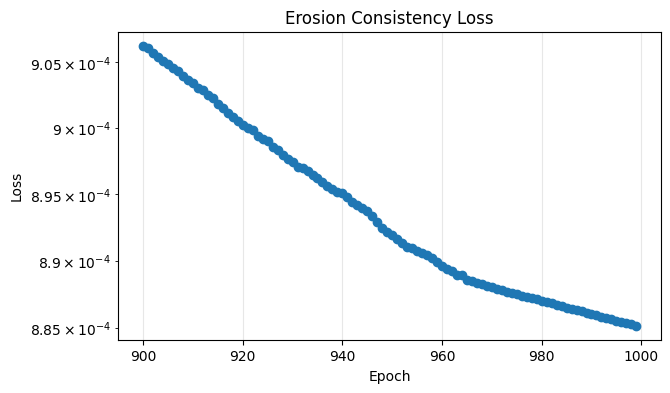

epoch 1000/1000 | loss = 0.000885 | lr = 0.0005


MountainGen(
  (encoders): ModuleList(
    (0-3): 4 x Linear(in_features=2, out_features=4, bias=True)
  )
  (noise): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Saw()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [19]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


epochs = 1000
steps_per_epoch = 5
learning_rate = 1e-3
seed = 2026
max_epoch_losses = 100
lr_decay_factor = 0.5
min_lr = 1e-7
grad_clip_norm = 1.0

value_loss_weight = 1.0
grad_loss_weight = 1.0

resolution = 128

dx = 2 / (resolution - 1)
dy = 2 / (resolution - 1)


torch.manual_seed(seed)
np.random.seed(seed)


def spatial_grads(h):
    gy, gx = torch.gradient(h, spacing=(dy, dx))
    return gx, gy


def has_nonfinite_params(model):
    return any(not torch.isfinite(p).all() for p in model.parameters())


x = offset[0] + np.linspace(-1, 1, resolution)
y = offset[1] + np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(x, y)

local_coords_t = torch.as_tensor(
    np.stack([xx.reshape(-1), yy.reshape(-1)], axis=-1),
    dtype=torch.float32,
).to(device)

# Start from a fresh model each run to avoid carrying over corrupted parameters.
eroded_model = MountainGen()
if has_nonfinite_params(eroded_model):
    raise RuntimeError("Freshly initialized model has non-finite parameters.")

eroded_model = eroded_model.to(device)
base_model = base_model.to(device)

eroded_model.train()
optimizer = torch.optim.Adam(eroded_model.parameters(), lr=learning_rate)

eroded_target_t = torch.as_tensor(eroded_height, dtype=torch.float32, device=device)
if eroded_target_t.shape != (resolution, resolution):
    raise ValueError(
        f"eroded_height shape {tuple(eroded_target_t.shape)} does not match (resolution, resolution) {(resolution, resolution)}"
    )


def surface_area(h):
    gx, gy = spatial_grads(h)
    return torch.sqrt(1.0 + gx.square() + gy.square()).sum() * dx * dy


target_surface_area = surface_area(eroded_target_t).detach()

prev_epoch_loss = None
epoch_losses = []
fig, ax = plt.subplots(figsize=(7, 4))

try:
    for epoch in range(1, epochs + 1):
        step_losses = []

        for _ in range(steps_per_epoch):
            pred = eroded_model(local_coords_t).reshape(resolution, resolution)
            if not torch.isfinite(pred).all():
                raise RuntimeError("Model prediction became non-finite.")

            mse_loss = torch.nn.functional.mse_loss(pred, eroded_target_t)
            pred_surface_area = surface_area(pred)
            area_loss = (
                (pred_surface_area - target_surface_area)
                / target_surface_area.clamp_min(1e-8)
            ).square()
            loss = value_loss_weight * mse_loss + grad_loss_weight * area_loss
            if not torch.isfinite(loss):
                raise RuntimeError("Loss became non-finite.")

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                eroded_model.parameters(), max_norm=grad_clip_norm
            )
            optimizer.step()

            step_losses.append(loss.detach().cpu().item())

        epoch_loss = float(np.mean(step_losses))

        if prev_epoch_loss is not None and epoch_loss > prev_epoch_loss:
            # decay learning rate
            for g in optimizer.param_groups:
                new_lr = max(g["lr"] * lr_decay_factor, min_lr)
                g["lr"] = new_lr
                learning_rate = new_lr
            print(
                f"  loss increased, decayed lr to {optimizer.param_groups[0]['lr']:.2e}"
            )

        prev_epoch_loss = epoch_loss

        epoch_losses.append(epoch_loss)
        if len(epoch_losses) > max_epoch_losses:
            epoch_losses.pop(0)

        clear_output(wait=True)

        ax.clear()
        ax.plot(
            range(epoch - len(epoch_losses), epoch),
            epoch_losses,
            marker="o",
            linewidth=1.5,
        )
        ax.set_yscale("log")
        ax.set_title("Erosion Consistency Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)

        display(fig)

        print(
            f"epoch {epoch:02d}/{epochs} | loss = {epoch_loss:.6f} | lr = {learning_rate}"
        )
except KeyboardInterrupt:
    pass


plt.close(fig)
eroded_model.eval()

In [20]:
offset = (0, 0)
r = 1
x, y, xx, yy, approx_eroded_height = evaluate_on_grid(
    eroded_model.cpu(), offset, x_range=(-r, r), y_range=(-r, r)
)
plot_landscape(x, y, xx, yy, approx_eroded_height)